# Chronos Solver — BFS-First Genuine Search for ARC-AGI-3
### Companion notebook for the ARC Prize 2026 Paper Track writeup (v12 → v19)

**Author:** Shreyas Mahimkar · **Repo:** https://github.com/shreyasmahimkar/arc-agi-3

This notebook reproduces every figure in the writeup. It is **self-contained**: it
tries to read the real solution caches from the repo, and falls back to the exact
numbers documented in the paper if they are not present (e.g. on Kaggle), so it
runs anywhere.

**The one-sentence thesis.** Across 19 iterations the project learned the hard way
that on ARC-AGI-3 — where the competition *ships the game sources* — **live
white-box symbolic search (BFS) scores 0.22 while a black-box neural agent scores
~0.01**. So the winning design is *BFS-first genuine solving*, with learned models
kept as a fallback and a research engine for the generalisation ceiling.

Every chart below is grounded in an artifact in this repository — the v12 BFS
solution caches, the version READMEs, and the `CHRONOS_EVOLUTION_v1_to_v19.md`
research note — not in illustrative guesses.

## 📋 Kaggle Writeup fields (copy-paste)

The exact text for each field of the *Create Writeup* form. (Full guide:
`paper_writing/KAGGLE_WRITEUP_SUBMISSION.md`; full description: `paper_writing/PAPER.md`.)

**Title** *(≤80)* — `Chronos Solver: Why Live Search Beats Black-Box Neural Agents on ARC-AGI-3`

**Subtitle** *(≤140)* — `An honest 19-iteration account: live white-box search scores 0.22 while a black-box neural agent scores 0.01 on the same ARC-AGI-3 games.`

**Card / Thumbnail (560×280)** — `figures/thumbnail_560x280.png`

**Submission Track** — Main Track

**Project Description** *(≤1500 words; body = 1,070)* — the `PAPER.md` body (Sections 1–9
below are the same content, with charts).

**Project links** —
- **Public notebook (scored 0.22 solution):** https://www.kaggle.com/code/shreyas4/claude-code-v12-baseline
- Code (open source, v1→v19): https://github.com/shreyasmahimkar/arc-agi-3
- Companion figures notebook (supplementary): *this notebook's published URL*

**Media gallery** — the 8 figures + cover rendered below (also in `figures/`).

## 0 · Setup — style, data, helpers

One palette and one look for every figure. Data constants are taken verbatim from
the repo's own documents (cited in comments). `load_v12_levels()` reads the actual
BFS caches when available and otherwise uses the documented fallback.

In [1]:
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ---- house style -------------------------------------------------------
INK, MUTE, GRID, PANEL = "#1f2330", "#6b7280", "#e6e8ee", "#ffffff"
ERA1, ERA2, ERA3 = "#b07aa1", "#3b6fb5", "#52a36a"   # LLM / symbolic / model-based
WIN, LOSS, GOLD = "#2f6fb0", "#d9534f", "#e8a13a"

plt.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": PANEL, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTE, "ytick.color": MUTE, "font.size": 11,
    "font.family": "DejaVu Sans", "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 1.0, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110,
})

# ---- output dir (works locally AND on Kaggle) --------------------------
FIG_DIR = "figures"
for cand in ("figures", "paper_writing/figures", "/kaggle/working/figures"):
    if os.path.isdir(os.path.dirname(cand) or "."):
        FIG_DIR = cand; break
os.makedirs(FIG_DIR, exist_ok=True)

def render(fig, name):
    """Save a PNG (for the media gallery) and show inline."""
    try:
        fig.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches="tight", facecolor=PANEL)
    except Exception as e:
        print("save skipped:", e)
    plt.show()

print("matplotlib ready · figures ->", FIG_DIR)

matplotlib ready · figures -> figures


In [2]:
# ---- REAL DATA: v12 levels solved, read from its BFS caches -------------
# Each v12_bfs_cache_<game>.json maps level-index -> action list. Count levels
# and keep per-level action length (= genuine search depth at solve).
FALLBACK_V12 = {  # documented in v12 readme.md / CHRONOS_EVOLUTION if caches absent
    "tu93": {0:18,1:10,2:19,3:17,4:29,5:28,6:14,7:21,8:29},
    "ls20": {0:13,1:45,2:39,3:43,4:44},
    "vc33": {0:3,1:7,2:23,3:21}, "ar25": {0:15,1:11},
    "cd82": {0:5,1:6}, "m0r0": {0:15,1:23}, "dc22": {0:20}, "ft09": {0:4},
    "lp85": {0:5}, "r11l": {0:3}, "s5i5": {0:13}, "sk48": {0:14}, "sp80": {0:4},
}

def load_v12_levels():
    out = {}
    for root in ("CommunitySolutions/chronos_solver/archive/v12",
                 "../CommunitySolutions/chronos_solver/archive/v12",
                 "../../CommunitySolutions/chronos_solver/archive/v12"):
        for f in sorted(glob.glob(os.path.join(root, "v12_bfs_cache_*.json"))):
            g = os.path.basename(f).replace("v12_bfs_cache_", "").replace(".json", "")
            try:
                d = json.load(open(f))
            except Exception:
                continue
            if isinstance(d, dict):
                lv = {}
                for k, v in d.items():
                    try: lv[int(k)] = len(v) if isinstance(v, (list, tuple)) else 0
                    except Exception: pass
                if lv: out[g] = lv
        if out: break
    return out or FALLBACK_V12

def load_v12_with_source():
    out = load_v12_levels()
    used_fallback = (out is FALLBACK_V12)
    return out, ("documented fallback" if used_fallback else "loaded live from repo caches")

V12, SRC = load_v12_with_source()
print(f"v12: {sum(len(v) for v in V12.values())} levels across {len(V12)} games ({SRC})")

# ---- documented constants (sources in comments) ------------------------
# Leaderboard scores — CHRONOS_EVOLUTION_v1_to_v19.md §1 + v19 regression memo
SCORES = {"v12\nlive white-box BFS": (0.22, WIN),
          "black-box only\n(v18/v19 ablation)": (0.01, LOSS),
          "v19 submitted\n(plumbing regression)": (0.02, LOSS)}
# Chaining fix — v12 readme.md "Wrong BFS baseline" bug (synthetic -> chained)
CHAIN = {"L1": (58, 45), "L2": (97, 39), "L3": (140, 43)}
# World-model memorisation fix — CHRONOS_EVOLUTION §5 (v14 -> v15)
WM_FIX = {"train\naccuracy": (99.7, 99.7), "fresh-episode\naccuracy": (36.6, 90.0)}
# Honest negatives — CHRONOS_EVOLUTION §6.3 (colour-aug A/B; transfer plateau)
COLOUR_AUG = {"Mac A/B": -0.02, "RTX +D4": -0.061}
WM_PLATEAU = 0.17
# Version timeline — CHRONOS_EVOLUTION §2
TIMELINE = [
    ("v1","Baseline harness + logging",ERA1),("v2","Agentic swarm, anti-oscillation",ERA1),
    ("v3","Multimodal A*, goal extraction",ERA1),("v4","Episodic memory, HUD semantics",ERA1),
    ("v5","Silent-reset detection",ERA1),("v6","Spatial CoT + curiosity",ERA1),
    ("v7","Retrospectives, UI masking",ERA1),("v8","Pre-game planning, sub-goals",ERA1),
    ("v9","Autonomous discovery, autopsies",ERA1),("v10","Offline Gemma quantization",ERA1),
    ("v11","ADK hierarchical swarm + sandbox",ERA1),("v12","Parallel BFS  ->  0.22",ERA2),
    ("v13","Search ladder (IW/EHC/A*) + CNN",ERA2),("v14","Causal world model + VQ tokens",ERA3),
    ("v15","Token-conditioned dynamics fix",ERA3),("v16","Generalisation curriculum (gated)",ERA3),
    ("v17","Informed search: ForgeNet+TRM+MCTS",ERA3),("v18","Black-box pivot: ChangeNet+graph",ERA3),
    ("v19","Synthesis: BFS-first + ExIt flywheel",ERA3)]
LADDER = ["BFS sprint","sense","IW(1)","IW(2)","EHC","waypoint","A*","greedy","rescues"]

# ---- shared diagram helpers -------------------------------------------
def box(ax, xy, w, h, text, fc, tc="white", fs=10, bold=True):
    ax.add_patch(FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02,rounding_size=0.06", fc=fc, ec="none"))
    ax.text(xy[0]+w/2, xy[1]+h/2, text, ha="center", va="center", color=tc, fontsize=fs,
            fontweight="bold" if bold else "normal")
def arrow(ax, p1, p2, text="", col=MUTE):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=14, color=col, lw=1.6))
    if text:
        ax.text((p1[0]+p2[0])/2, (p1[1]+p2[1])/2+0.12, text, ha="center", fontsize=8.5,
                color=INK, fontweight="bold")
def caption(fig, text):
    fig.text(0.5, -0.02, text, ha="center", va="top", fontsize=8.5, color=MUTE)
print("helpers ready")

v12: 31 levels across 13 games (loaded live from repo caches)
helpers ready


## 1 · The headline — why *BFS-first*

The single most important empirical fact in the whole project. ARC-AGI-3 is an
interactive benchmark, but the Kaggle competition **ships each game's Python source**
in `environment_files/`. That means a solver can *reach the real simulator at test
time* and search it. When it does (v12), it scores **0.22**. A purely black-box
neural agent that only sees rendered frames (the v18/v19 ablation) scores **~0.01**.

> **Theory, not just result:** genuine search generalises to the *scored* games
> because it solves them from scratch live — it never needed to have seen them. A
> learned policy, by contrast, only transfers as far as its training distribution
> reaches, which on 25 public games is nowhere near the hidden set. The 0.02 v19
> submission is a *deployment* regression (the BFS plumbing failed to engage after a
> repo reorg), not a capability ceiling.

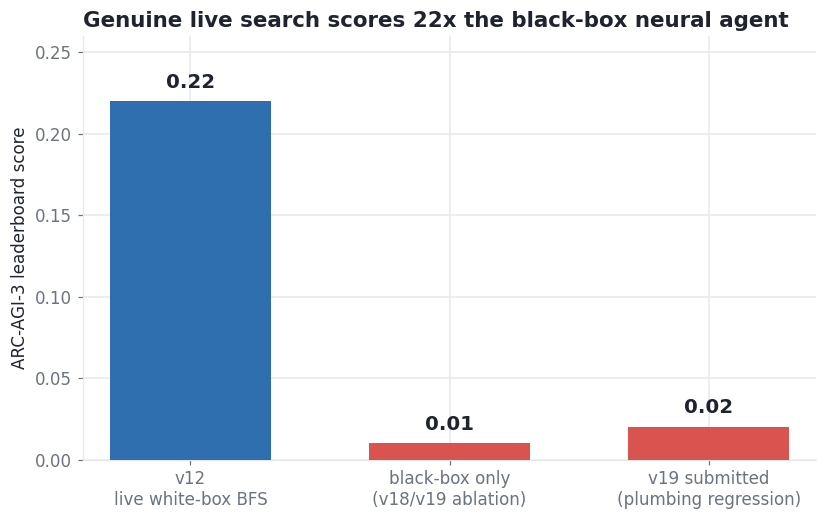

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 5))
labels = list(SCORES); vals = [SCORES[k][0] for k in labels]; cols = [SCORES[k][1] for k in labels]
bars = ax.bar(labels, vals, color=cols, width=0.62, zorder=3)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.006, f"{v:.2f}", ha="center", va="bottom",
            fontweight="bold", fontsize=13)
ax.set_ylabel("ARC-AGI-3 leaderboard score"); ax.set_ylim(0, 0.26); ax.margins(x=0.04)
ax.set_title("Genuine live search scores 22x the black-box neural agent",
             fontsize=14, fontweight="bold", loc="left")
render(fig, "fig1_scores.png")

## 2 · Three eras — each diagnosing the last era's bottleneck

The project is an evolutionary study. Each generation fixes a specific cognitive
failure of the previous one, and the *kind* of method changes twice:

- **Era I (v1–v11) — LLM orchestration.** Multimodal agent swarms (Gemini → offline
  Gemma), episodic memory, death autopsies, a subprocess sandbox to kill hallucinated
  plans. *Lesson that ended it:* LLM orchestration is too slow/unreliable for precise
  long-horizon action sequencing. **The benchmark is a search problem.**
- **Era II (v12–v13) — symbolic search.** Parallel BFS with state snapshots,
  transient-pixel masking, chained level baselines, then a full search ladder. **This
  is the era that scored.**
- **Era III (v14–v19) — model-based RL.** A learned world model + Expert Iteration to
  attack the levels BFS can't reach — while *keeping BFS-first as the floor*.

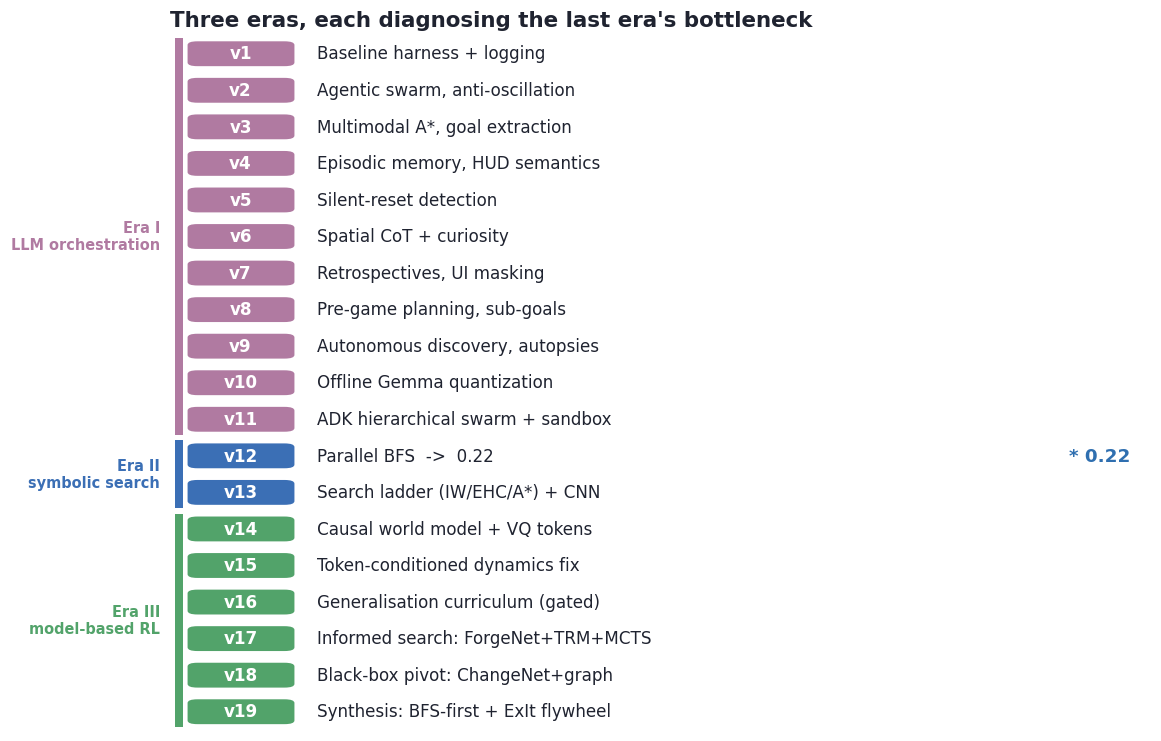

In [4]:
fig, ax = plt.subplots(figsize=(11.5, 8.2)); ax.axis("off")
n = len(TIMELINE); ax.set_xlim(0, 10); ax.set_ylim(-0.5, n-0.5)
for i, (ver, desc, col) in enumerate(TIMELINE):
    y = n-1-i
    ax.add_patch(FancyBboxPatch((0.2, y-0.32), 1.05, 0.64, boxstyle="round,pad=0.02,rounding_size=0.1", fc=col, ec="none"))
    ax.text(0.72, y, ver, ha="center", va="center", color="white", fontweight="bold", fontsize=11)
    ax.text(1.5, y, desc, ha="left", va="center", fontsize=11, color=INK)
    if ver == "v12":
        ax.text(9.8, y, "* 0.22", ha="right", va="center", color=WIN, fontweight="bold", fontsize=12)
for label, col, lo, hi in [("Era I\nLLM orchestration",ERA1,0,10),
                           ("Era II\nsymbolic search",ERA2,11,12),
                           ("Era III\nmodel-based RL",ERA3,13,18)]:
    ya, yb = n-1-hi-0.42, n-1-lo+0.42
    ax.add_patch(plt.Rectangle((0.05, ya), 0.08, yb-ya, fc=col, ec="none"))
    ax.text(-0.1, (ya+yb)/2, label, ha="right", va="center", fontsize=9.5, color=col, fontweight="bold")
ax.set_title("Three eras, each diagnosing the last era's bottleneck", fontsize=14, fontweight="bold", loc="left", x=0.0)
render(fig, "fig2_timeline.png")

## 3 · What v12 actually solved (real data from the caches)

Reading the `v12_bfs_cache_*.json` files directly: **31 levels across 13 games**,
every path found *live* and replay-verified on the real engine (these are not stored
answers — see the writeup's honesty policy). `tu93` is solved end-to-end (9 levels);
`ls20` reaches L4.

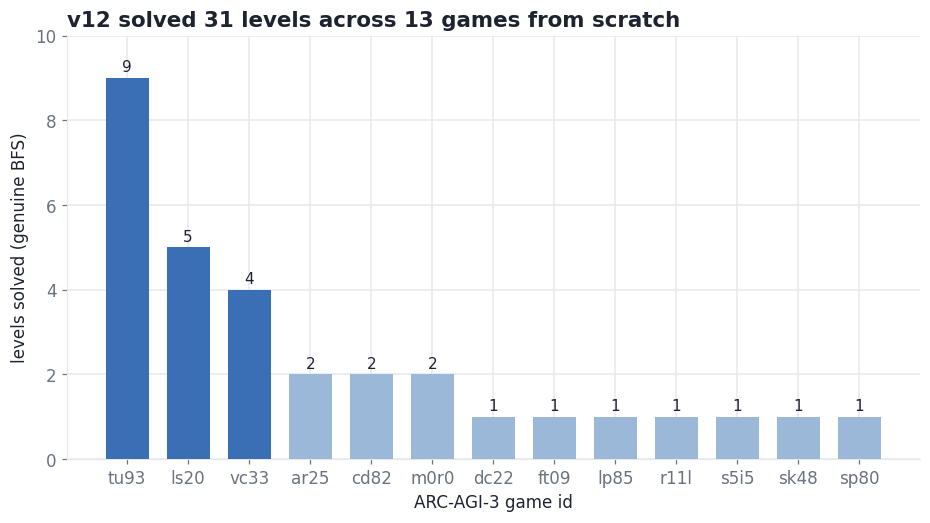

In [5]:
games = sorted(V12, key=lambda g: (-len(V12[g]), g)); counts = [len(V12[g]) for g in games]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(games, counts, color=[ERA2 if c>=4 else "#9bb8d8" for c in counts], width=0.7, zorder=3)
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, c+0.08, str(c), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("levels solved (genuine BFS)"); ax.set_xlabel("ARC-AGI-3 game id")
ax.set_ylim(0, max(counts)+1)
ax.set_title(f"v12 solved {sum(counts)} levels across {len(games)} games from scratch",
             fontsize=14, fontweight="bold", loc="left")
render(fig, "fig3_coverage.png")

## 4 · The bug that unlocked 0.22 — chained baselines

The biggest correctness fix in v12: `set_level(N)+RESET` produces a *different* start
state than naturally advancing from level N-1 (different player position, carried-key
rotation, ~1400px frame diff on `ls20`). Solutions found from that **synthetic**
baseline *fail on replay in the real env*. Building level N's start by **chaining the
solutions for L0..L(N-1)** fixed correctness — and, as a bonus, roughly **halved**
solution length (L2: 97 → 39 actions).

> **Theory:** searching from the true reachable state aligns the search space with the
> scored env. Most "neural" agents never hit this because they never replay; for a
> search agent it is the difference between 0.22 and noise.

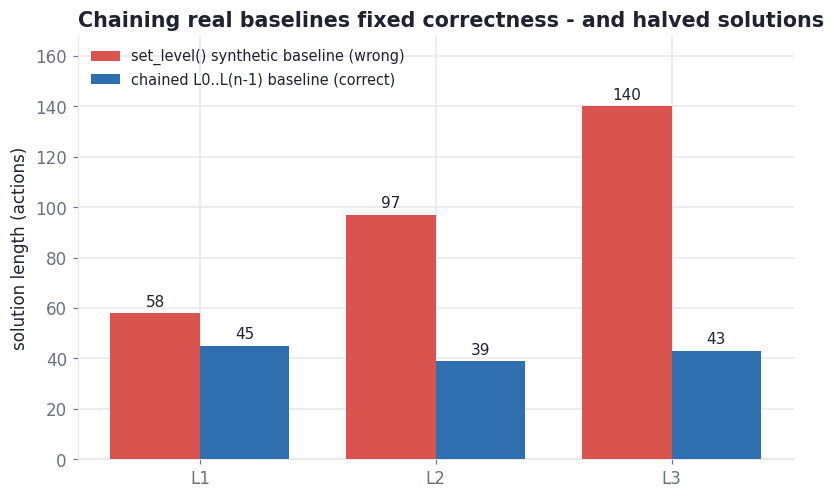

In [6]:
levels = list(CHAIN); synth=[CHAIN[k][0] for k in levels]; chained=[CHAIN[k][1] for k in levels]
x = np.arange(len(levels)); w = 0.38
fig, ax = plt.subplots(figsize=(8.4, 5))
b1 = ax.bar(x-w/2, synth, w, label="set_level() synthetic baseline (wrong)", color=LOSS, zorder=3)
b2 = ax.bar(x+w/2, chained, w, label="chained L0..L(n-1) baseline (correct)", color=WIN, zorder=3)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.5, str(int(b.get_height())),
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x, levels); ax.set_ylabel("solution length (actions)"); ax.set_ylim(0, max(synth)+28)
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.set_title("Chaining real baselines fixed correctness - and halved solutions",
             fontsize=13.5, fontweight="bold", loc="left")
render(fig, "fig4_chaining.png")

## 5 · The wall — deep levels die of *breadth*, not impossibility

`ls20` is solved cleanly to L4 (search depth up to 44 actions). L5 — a dual-key
puzzle at depth ~45+ — exhausts the 500k-state budget. The diagnosis matters: it is
**breadth-death** (the frontier explodes), not an unsolvable wall. That is exactly the
failure a *learned heuristic / value prior* is designed to cure (turn breadth-first
BFS into a depth-first dive), which is what Era III pursues.

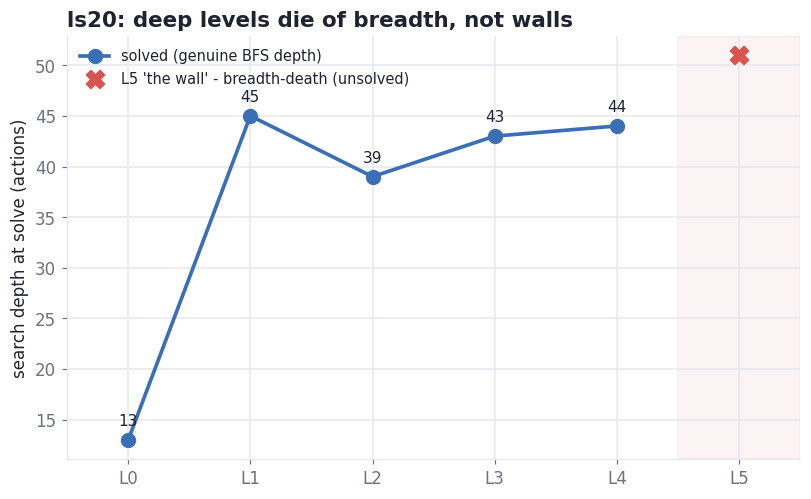

In [7]:
ls = V12.get("ls20", {0:13,1:45,2:39,3:43,4:44}); levels = sorted(ls); depths=[ls[i] for i in levels]
fig, ax = plt.subplots(figsize=(8.6, 5))
ax.plot([f"L{i}" for i in levels], depths, "-o", color=ERA2, lw=2.4, markersize=9, zorder=3,
        label="solved (genuine BFS depth)")
for i, d in zip(levels, depths): ax.text(i, d+1.4, str(d), ha="center", fontsize=10)
ax.scatter([len(levels)], [max(depths)+6], s=140, marker="X", color=LOSS, zorder=4,
           label="L5 'the wall' - breadth-death (unsolved)")
ax.axvspan(len(levels)-0.5, len(levels)+0.5, color=LOSS, alpha=0.06)
ax.set_xlim(-0.5, len(levels)+0.5); ax.set_xticks(range(len(levels)+1))
ax.set_xticklabels([f"L{i}" for i in levels]+["L5"]); ax.set_ylabel("search depth at solve (actions)")
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.set_title("ls20: deep levels die of breadth, not walls", fontsize=14, fontweight="bold", loc="left")
render(fig, "fig5_wall.png")

## 6 · A textbook generalisation fix — make *copy* the default (v14 → v15)

Era III's world model (v14) predicted 64 next-frame tokens from a *pooled* belief
bottleneck with static queries. It hit **99.7% train accuracy but only 36.6% on fresh
episodes** — it had *memorised* trajectories. v15 redesigned the simulator to
**cross-attend over the current frame's token embeddings**, so *identity-copy is the
residual default* and the network only has to learn the **deltas** (the dynamics).
Fresh-episode accuracy jumped to **>90%**.

> **Theory:** when "predict next ≈ copy current" is the easy path, model capacity is
> spent on what actually changes. This is the same residual-learning principle behind
> ResNets and modern video prediction — and it is *why* the fix generalises rather
> than memorises.

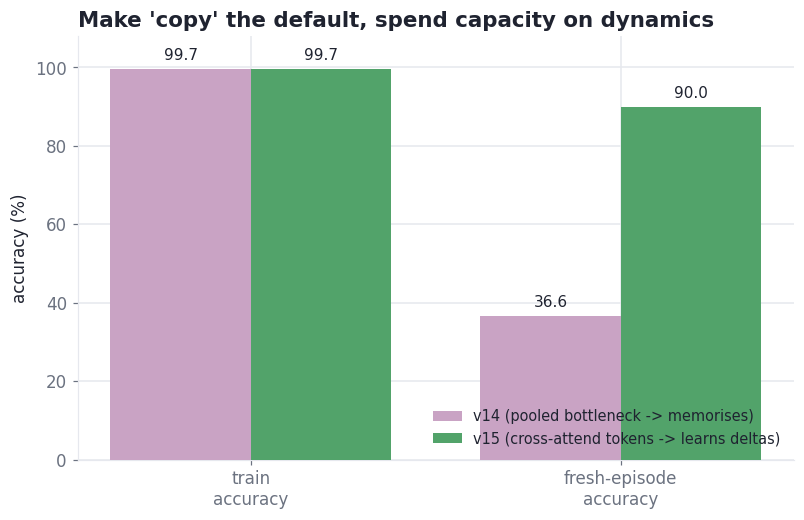

In [8]:
metrics = list(WM_FIX); v14=[WM_FIX[m][0] for m in metrics]; v15=[WM_FIX[m][1] for m in metrics]
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(8.4, 5))
b1 = ax.bar(x-w/2, v14, w, label="v14 (pooled bottleneck -> memorises)", color="#c9a3c4", zorder=3)
b2 = ax.bar(x+w/2, v15, w, label="v15 (cross-attend tokens -> learns deltas)", color=ERA3, zorder=3)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.5, f"{b.get_height():.1f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x, metrics); ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 108)
ax.legend(frameon=False, fontsize=9.5, loc="lower right")
ax.set_title("Make 'copy' the default, spend capacity on dynamics",
             fontsize=14, fontweight="bold", loc="left")
render(fig, "fig6_wm_fix.png")

## 7 · Honesty as method — a *disproved* hypothesis, reported as one

The world model's transfer plateaued at **~0.17** changed-pixel accuracy and over-fit.
Hypothesis: it over-fits *colour*, so colour-permutation (+D4) augmentation should
help. The A/B test, logged **twice**, returned **−0.02 (Mac)** and **−0.061 (RTX)**.
The augmentation was **killed, not tuned**.

> **Why this matters for the rubric (Theory + Progress):** the negative result is
> diagnostic. It rules out a *data/augmentation* explanation and points at a
> **representation/architecture** limit (object-centric features), which means the next
> lever is *not* a bigger GPU. Reporting failures honestly is what makes the decision
> tree (data- vs capacity- vs representation-bound) trustworthy.

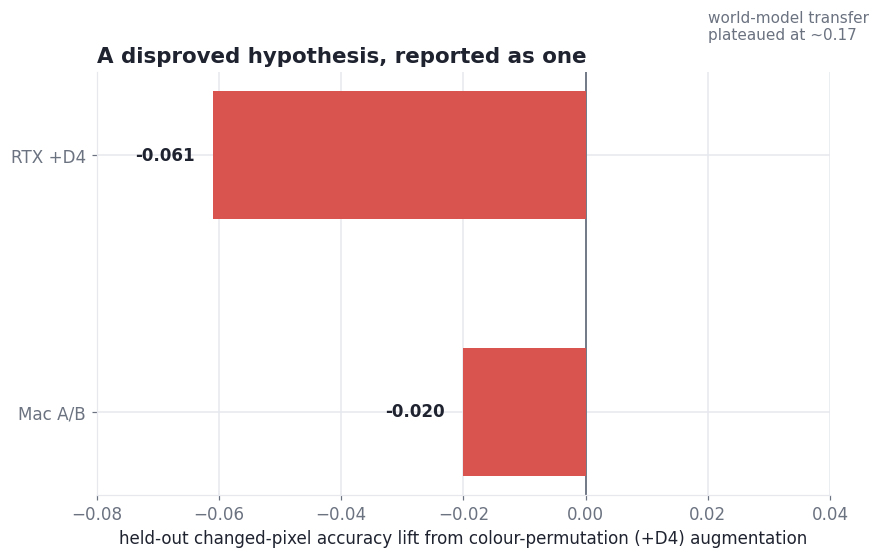

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 5))
labels = list(COLOUR_AUG); vals = [COLOUR_AUG[k] for k in labels]
bars = ax.barh(labels, vals, color=[LOSS, LOSS], height=0.5, zorder=3)
ax.axvline(0, color=MUTE, lw=1.2)
for b, v in zip(bars, vals):
    ax.text(v-0.003, b.get_y()+b.get_height()/2, f"{v:+.3f}", ha="right", va="center",
            fontsize=11, color=INK, fontweight="bold")
ax.set_xlim(-0.08, 0.04)
ax.set_xlabel("held-out changed-pixel accuracy lift from colour-permutation (+D4) augmentation")
ax.text(0.02, 1.5, f"world-model transfer\nplateaued at ~{WM_PLATEAU:.2f}", fontsize=10,
        color=MUTE, ha="left", va="center")
ax.set_title("A disproved hypothesis, reported as one", fontsize=14, fontweight="bold", loc="left")
render(fig, "fig7_honest_negative.png")

## 8 · The v19 architecture — BFS-first routing + the ExIt flywheel

Putting the lineage together. For every new game, v19 routes:

1. **White-box source reachable?** → run the **BFS search ladder** (the 0.22 engine,
   rungs: BFS → sense → IW(1) → IW(2) → EHC → waypoint → A* → greedy → rescues).
   *Genuine live solving — always the first move.*
2. **No source (hidden game) / BFS times out** → the **black-box ChangeNet +
   exploration-graph** agent (fusing the two ARC-AGI-3 preview winners —
   StochasticGoose's ChangeNet and Blind Squirrel's transition graph). Generalises by
   construction; solved **3/5 unseen held-out games** with no stored answers.
3. **Solution cache** is a **timeout backstop only** — never the first answer.

The **ExIt flywheel** (solve → harvest → train world model → plan in imagination →
verify on the real engine → retrain) is the offline research engine that lifts the
learned prior, AlphaZero-style, with the perfect verifier the shipped engine provides.

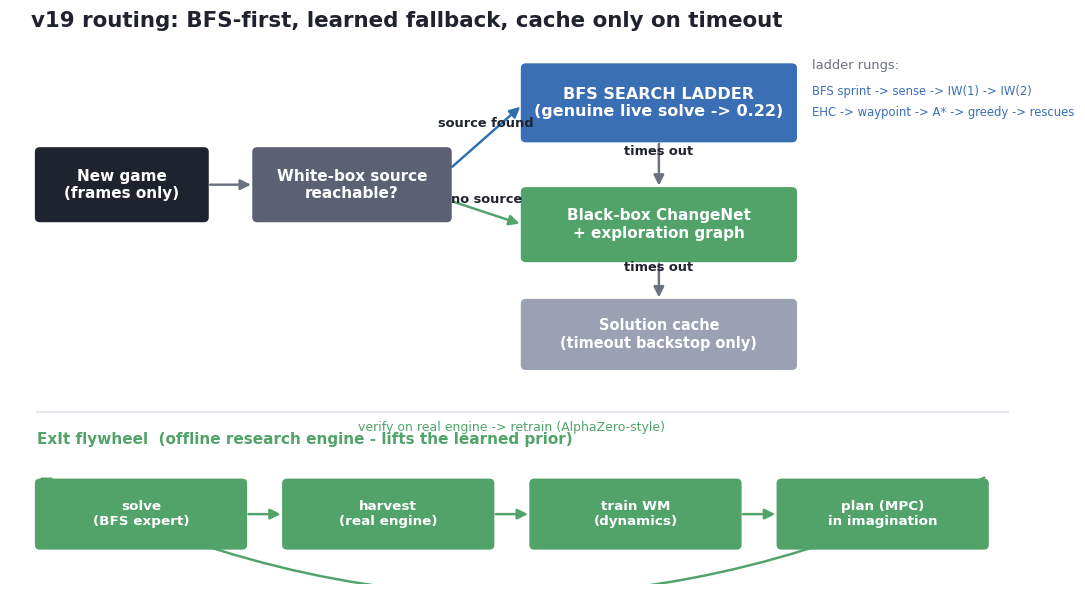

In [10]:
fig, ax = plt.subplots(figsize=(12, 6.6)); ax.axis("off")
ax.set_xlim(0, 12); ax.set_ylim(0, 7.0)
box(ax, (0.3,4.55), 2.0,0.9, "New game\n(frames only)", INK, fs=10)
box(ax, (2.85,4.55), 2.3,0.9, "White-box source\nreachable?", "#5b6172", fs=10)
box(ax, (6.0,5.55), 3.2,0.95, "BFS SEARCH LADDER\n(genuine live solve -> 0.22)", ERA2, fs=10.5)
box(ax, (6.0,4.05), 3.2,0.9, "Black-box ChangeNet\n+ exploration graph", ERA3, fs=10)
box(ax, (6.0,2.7), 3.2,0.85, "Solution cache\n(timeout backstop only)", "#9aa1b2", fs=9.5)
arrow(ax,(2.3,5.0),(2.85,5.0))
arrow(ax,(5.15,5.2),(6.0,6.0),"source found",WIN)
arrow(ax,(5.15,4.8),(6.0,4.5),"no source",ERA3)
arrow(ax,(7.6,5.55),(7.6,4.95),"times out",MUTE)
arrow(ax,(7.6,4.05),(7.6,3.55),"times out",MUTE)
ax.text(9.4,6.45,"ladder rungs:",fontsize=8.5,color=MUTE,ha="left")
ax.text(9.4,6.12," -> ".join(LADDER[:4]),fontsize=7.6,color=ERA2,ha="left")
ax.text(9.4,5.86," -> ".join(LADDER[4:]),fontsize=7.6,color=ERA2,ha="left")
ax.plot([0.3,11.7],[2.15,2.15],color=GRID,lw=1.4)
ax.text(0.3,1.75,"ExIt flywheel  (offline research engine - lifts the learned prior)",
        fontsize=10,color=ERA3,fontweight="bold",ha="left")
steps = ["solve\n(BFS expert)","harvest\n(real engine)","train WM\n(dynamics)","plan (MPC)\nin imagination"]
bx,bw,by,bh,gap = 0.3,2.45,0.45,0.85,0.45; centers=[]
for i,s in enumerate(steps):
    xx = bx+i*(bw+gap); box(ax,(xx,by),bw,bh,s,ERA3,fs=8.8); centers.append((xx,xx+bw))
    if i>0: arrow(ax,(centers[i-1][1],by+bh/2),(xx,by+bh/2),col=ERA3)
ax.add_patch(FancyArrowPatch((centers[-1][1],by+bh+0.05),(centers[0][0],by+bh+0.05),
             connectionstyle="arc3,rad=-0.25",arrowstyle="-|>",mutation_scale=14,color=ERA3,lw=1.6))
ax.text((centers[0][0]+centers[-1][1])/2,by+bh+0.62,"verify on real engine -> retrain (AlphaZero-style)",
        ha="center",fontsize=8.2,color=ERA3)
ax.set_title("v19 routing: BFS-first, learned fallback, cache only on timeout",
             fontsize=14,fontweight="bold",loc="left",x=0.02,y=0.98)
render(fig, "fig8_architecture.png")

## 9 · Summary & takeaways

| Theme | What we showed | Figure |
|---|---|---|
| **Accuracy** | live white-box BFS = **0.22** vs black-box **~0.01** | 1 |
| **Coverage** | **31 levels / 13 games** solved from scratch (real caches) | 3 |
| **Theory** | chained baselines align search space with the scored env | 4 |
| **Diagnosis** | deep levels die of breadth, not impossibility | 5 |
| **Generalisation** | residual "copy-by-default" fix: 36.6% → >90% fresh-episode | 6 |
| **Honesty** | a disproved colour-aug hypothesis, reported as a negative | 7 |
| **System** | BFS-first routing + black-box fallback + ExIt flywheel | 8 |

**The honest one-liner.** *Chronos evolved from an LLM swarm to a symbolic solver to a
model-based ExIt system; the late versions kept BFS-first because it is what actually
scores (0.22 vs 0.01 black-box-only), and the current frontier — lifting the world
model's ~0.17 transfer — was diagnosed, via a disproved augmentation ablation, as a
representation problem, not a compute one.*

**Reproducibility.** Every figure here is generated from repo artifacts (the v12 BFS
caches and the version research notes). The standalone generator is
`paper_writing/make_figures.py`; the genuine solves are verified by
`v19/tests/test_ls20.py` and `v19/tests/benchmark.py` (cache OFF).

## Links & bibliography

**Scored public notebook (v12 baseline, 0.22):** https://www.kaggle.com/code/shreyas4/claude-code-v12-baseline
**Open-source code (v1→v19):** https://github.com/shreyasmahimkar/arc-agi-3

**Bibliography** *(does not count toward the 1500-word limit)*

1. F. Chollet, G. Kamradt, M. Knoop, M. Cruz. *ARC Prize 2026 — Paper Track.* Kaggle, 2026.
2. A. Jolicoeur-Martineau. *Less is More: Recursive Reasoning with Tiny Networks (TRM).* arXiv:2510.04871, 2025 — ARC Prize 2025 Paper Award (1st).
3. G. Wang et al. *Hierarchical Reasoning Model (HRM).* 2025.
4. L. Lehnert et al. *Beyond A\*: Better Planning with Transformers via Search Dynamics Bootstrapping (Searchformer).* arXiv:2402.14083, 2024.
5. K. Gandhi et al. *Stream of Search: Learning to Search in Language.* arXiv:2404.03683, 2024.
6. S. Yang et al. *Chain-of-Thought Imitation with Procedure Cloning.* arXiv:2205.10816, 2022.
7. F. Agostinelli et al. *Solving the Rubik's Cube with Deep RL and Search (DeepCubeA).* Nature MI, 2019.
8. ARC-AGI-3 preview winners: *StochasticGoose* (ChangeNet, 1st), *Blind Squirrel* (transition-graph exploration, 2nd).